In [39]:
characters = {
    "柯碧舟": ["柯碧舟", "小柯", "碧舟"],
    "杜见春": ["杜见春", "见春"],
    "苏道诚": ["苏道诚", "小苏"],
    "王连发": ["王连发", "小王"],
    "肖永川": ["肖永川"],
    "唐惠娟": ["唐惠娟", "小唐", "惠娟"],
    "华雯雯": ["华雯雯", "雯雯", "华姑娘"],
    "邵大山": ["邵大山", "大山伯", "大山哥", "幺公"],
    "邵玉蓉": ["邵玉蓉", "玉蓉"],
    "左定法": ["左定法", "左主任"]
}

character_fullnames = set(characters.keys())

with open("data/cuotuo_suiyue_resolved.txt", "r") as f:
  text = f.read()

#with open("data/cuotuo_suiyue.txt", "r") as f:
#  text = f.read()

print(len(text))

import re

# Build a lookup dictionary from variant -> canonical
lookup = {}
for canonical, variants in characters.items():
    for v in variants:
        lookup[v] = canonical

# Sort variants by length (longest first to avoid partial replacements)
all_variants = sorted(lookup.keys(), key=len, reverse=True)

# Build regex that matches any variant
pattern = re.compile("|".join(map(re.escape, all_variants)))

def normalize(text):
    return pattern.sub(lambda m: lookup[m.group(0)], text)

normalized_text = normalize(text)

print(len(normalized_text))

287216
288017


In [42]:
character_space = {character : 0 for character in characters.keys()}
character_interiority_count = {character : 0 for character in characters.keys()}

import jieba
for fullname in characters.keys():
  jieba.add_word(fullname)

target_words = set(["心里", "心中", "心上", "心头", "心下", 
                "心内", "满心", "内心", "胸中", "心底", 
                "心口", "心间", "心肝", "肚里", "腹内", 
                "胸口", "心坎", "心房", "脑子里", "一肚子", 
                "肺腑", "心脏", "脑海", "眼里"])
for word in target_words:
  jieba.add_word(word)

all_words = jieba.lcut(normalized_text)

how_many_interiority = sum(word in target_words for word in all_words)

print(f"How many interiority: {how_many_interiority},\ntotal words: {len(all_words)},\none interiority per how many words: {len(all_words)/how_many_interiority}")

window = 10
for word_index, word in enumerate(all_words):
  if word in characters.keys(): # if we bumped into a character
    start_index = max(0, word_index-10)
    end_index = min(len(all_words), word_index+window+1)
    current_character_space = all_words[start_index:end_index]
    character_space[word] += len(current_character_space)
    for context_word in current_character_space:
      if context_word in target_words:
        character_interiority_count[word] += 1

count_interiority_total = sum(word in target_words for word in all_words)
interiority_prob = count_interiority_total / len(all_words)

for character in characters.keys():
  print(f"Character: {character}")
  print(f"Interiority appeared: {character_interiority_count[character]}")
  print(f"Should appear: {round(interiority_prob*character_space[character],3)}")

How many interiority: 341,
total words: 184681,
one interiority per how many words: 541.5865102639297
Character: 柯碧舟
Interiority appeared: 196
Should appear: 132.058
Character: 杜见春
Interiority appeared: 195
Should appear: 115.234
Character: 苏道诚
Interiority appeared: 19
Should appear: 22.761
Character: 王连发
Interiority appeared: 6
Should appear: 7.484
Character: 肖永川
Interiority appeared: 14
Should appear: 11.865
Character: 唐惠娟
Interiority appeared: 10
Should appear: 7.522
Character: 华雯雯
Interiority appeared: 8
Should appear: 8.918
Character: 邵大山
Interiority appeared: 27
Should appear: 12.873
Character: 邵玉蓉
Interiority appeared: 64
Should appear: 41.334
Character: 左定法
Interiority appeared: 5
Should appear: 10.896


In [5]:
!pip install qhchina
from qhchina import load_fonts
load_fonts()

  Using cached qhchina-0.0.57-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.6 kB)
  Using cached numpy-2.3.4-cp313-cp313-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached scipy-1.16.3-cp313-cp313-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached matplotlib-3.10.7-cp313-cp313-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached scikit_learn-1.7.2-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached pandas-2.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp313-cp313-macosx_10_13_universal2.whl.metadata (112 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pillow-12.0.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.

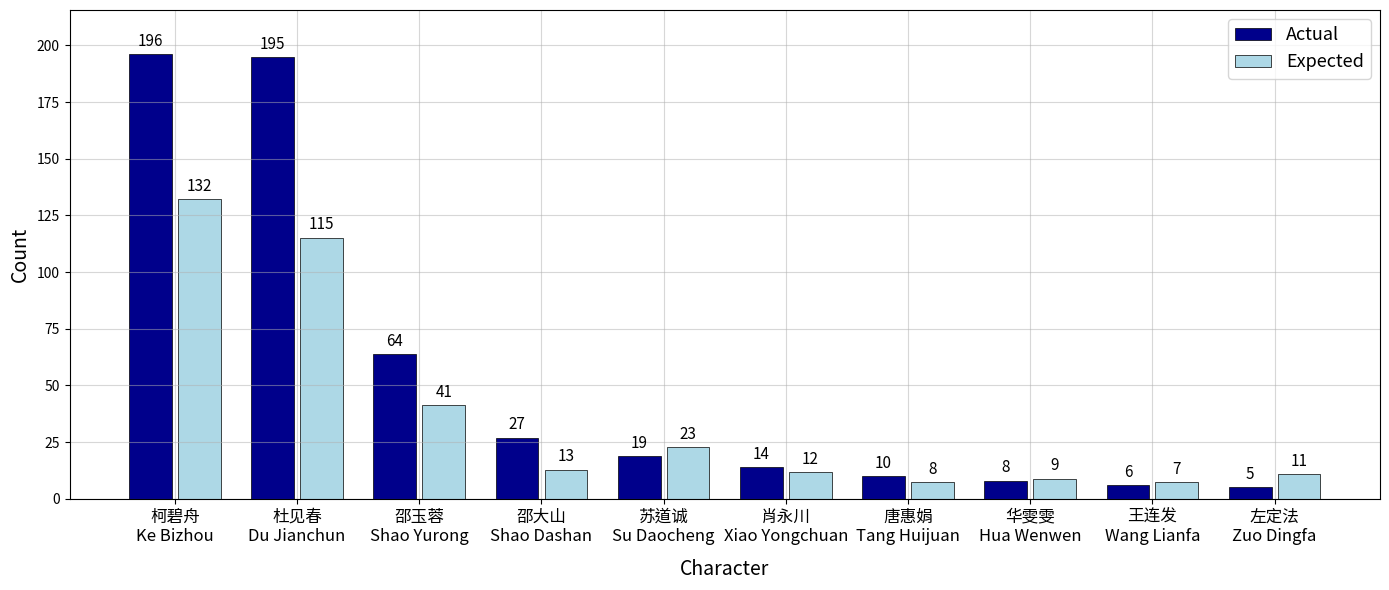

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# --- Compute expected values ---
character_heart_expected = {
    char: round(interiority_prob * character_space[char], 3)
    for char in characters.keys()
}

# --- Sort by actual occurrences (descending) ---
sorted_chars = sorted(
    characters.keys(),
    key=lambda c: character_interiority_count[c],
    reverse=True
)

actual = [character_interiority_count[c] for c in sorted_chars]
expected = [character_heart_expected[c] for c in sorted_chars]

x = np.arange(len(sorted_chars))
bar_width = 0.35
gap = 0.05  # space between two bars

fig, ax = plt.subplots(figsize=(14, 6))

rects1 = ax.bar(
    x - (bar_width/2 + gap/2), actual,
    width=bar_width,
    label="Actual",
    edgecolor="black", linewidth=0.5,
    color="darkblue"
)
rects2 = ax.bar(
    x + (bar_width/2 + gap/2), expected,
    width=bar_width,
    label="Expected",
    edgecolor="black", linewidth=0.5,
    color="lightblue"
)

# Add labels above each bar
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{int(round(height))}',
                xy=(rect.get_x() + rect.get_width()/2, height),
                xytext=(0, 3),  # offset up
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11)

# Increase ylim to fit labels
max_val = max(max(actual), max(expected))
ax.set_ylim(0, max_val * 1.1)

ax.set_ylabel("Count", fontsize=14)
ax.set_xlabel("Character", fontsize=14, labelpad=10)
ax.set_xticks(x)
translations = {"柯碧舟": "Ke Bizhou", 
                "杜见春": "Du Jianchun", 
                "邵玉蓉": "Shao Yurong", 
                "邵大山": "Shao Dashan", 
                "苏道诚": "Su Daocheng", 
                "华雯雯": "Hua Wenwen", 
                "肖永川": "Xiao Yongchuan", 
                "唐惠娟": "Tang Huijuan", 
                "王连发": "Wang Lianfa", 
                "左定法": "Zuo Dingfa"}
xticklabels = [sorted_chars[i] + "\n" + translations[sorted_chars[i]] for i in range(len(sorted_chars))]
ax.set_xticklabels(xticklabels, fontsize=12)
ax.legend(fontsize=13)

plt.grid(alpha=0.5)
plt.tight_layout()
plt.savefig("images/characters_heart_bar.png", dpi=300)
plt.show()
plt.close()

In [ ]:
import os
contemporary_novels = os.listdir("segmenter/data/contemporary_novels")
print(contemporary_novels)